# 04 — Baselines (LogReg, KNN, RF default)

**Objetivo**: establecer la línea base de rendimiento con tres modelos de
familias distintas, antes de cualquier hyperparameter tuning. Sirve para:

1. Cuantificar qué tan difícil es la tarea (si todos sacan F1 = 0.99, no
   hace falta tunear; si todos sacan 0.5, hay algo mal en el dataset).
2. Decidir en qué familia invertir esfuerzo de tuning (notebook 05).
3. Tener un piso reproducible contra el cual comparar.

**Inputs**: `datasets/processed/cicids_features_47.parquet` (output del
notebook 03).

**Outputs**:
- `datasets/processed/cicids_split.parquet`: columna `split` ∈ {train, val,
  test} para reuso en notebooks 05+.
- Tabla comparativa de baselines.

---

## Modelos elegidos

| Modelo | Familia | Por qué incluirlo |
|---|---|---|
| **Logistic Regression** | Lineal | Baseline mínimo. Si LogReg ya saca F1 alto, el problema es linealmente separable y no necesita modelos complejos. |
| **KNN** | Lazy / instance-based | Mide cuán "estructurado" es el espacio de features. Si KNN funciona, hay clusters claros por clase. |
| **Random Forest** | Ensemble de árboles | Robusto, captura interacciones no-lineales sin requerir scaling. Suele ser un baseline fuerte en datasets tabulares. |

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets', 'processed'))
IN_PATH = os.path.join(PROCESSED_DIR, 'cicids_features_47.parquet')
SPLIT_OUT = os.path.join(PROCESSED_DIR, 'cicids_split.parquet')
print(f"Input:  {IN_PATH}")

Input:  /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/datasets/processed/cicids_features_47.parquet


In [2]:
df = pd.read_parquet(IN_PATH)
features = [c for c in df.columns if c not in ('Day', 'Label_6')]
print(f"Shape: {df.shape}")
print(f"Features: {len(features)}")
print(f"Distribución Label_6:\n{df['Label_6'].value_counts()}")

Shape: (2313810, 49)
Features: 47
Distribución Label_6:
Label_6
Benign            1977318
DoS                193756
DDoS               128014
Brute Force          9150
Reconnaissance       3429
Web Attack           2143
Name: count, dtype: int64


## 1. Split estratificado 70/15/15

Estratificamos por la combinación `(Day, Label_6)` para que cada split
contenga una proporción similar de cada combinación día-clase. Esto
preserva tanto la distribución de clases como la estructura temporal del
dataset.

**Por qué importa la estratificación temporal**: CICIDS2017 captura cada
ataque en un día específico. Si no estratificamos por día, podríamos
terminar con todo el `Brute Force` del martes en train y nada en test, y el
modelo no tendría con qué evaluarse en esa clase.

In [3]:
# Composite stratification key
df['_strat_key'] = df['Day'].astype(str) + '__' + df['Label_6']

# Algunas combinaciones (Día, Label_6) tienen muy pocas muestras
# (ej: Heartbleed con 11 filas). Las que tengan < 3 muestras las metemos en
# train completas (no se pueden estratificar sino).
counts = df['_strat_key'].value_counts()
rare_keys = counts[counts < 3].index.tolist()
print(f"Combinaciones (Day, Label_6) con < 3 muestras: {len(rare_keys)}")
for k in rare_keys:
    print(f"  - {k}: {counts[k]}")

rare_mask = df['_strat_key'].isin(rare_keys)
df_rare = df[rare_mask]
df_normal = df[~rare_mask]

Combinaciones (Day, Label_6) con < 3 muestras: 0


In [4]:
# Split 70/15/15 con seed fijo
SEED = 42

train_normal, temp = train_test_split(
    df_normal, test_size=0.30, stratify=df_normal['_strat_key'], random_state=SEED
)
val, test = train_test_split(
    temp, test_size=0.50, stratify=temp['_strat_key'], random_state=SEED
)

# Asignar columna split para persistir.
# Importante: usamos los índices ORIGINALES de df (preservados por
# train_test_split). df_rare se asigna directo al train también.
df['split'] = 'unknown'
df.loc[train_normal.index, 'split'] = 'train'
df.loc[df_rare.index, 'split'] = 'train'
df.loc[val.index, 'split'] = 'val'
df.loc[test.index, 'split'] = 'test'

print(f"Total:  {len(df):>10,}")
print(f"Train:  {(df['split']=='train').sum():>10,}  ({(df['split']=='train').mean()*100:.1f}%)")
print(f"Val:    {(df['split']=='val').sum():>10,}  ({(df['split']=='val').mean()*100:.1f}%)")
print(f"Test:   {(df['split']=='test').sum():>10,}  ({(df['split']=='test').mean()*100:.1f}%)")
print(f"Unknown: {(df['split']=='unknown').sum()} (debe ser 0)")

Total:   2,313,810
Train:   1,619,667  (70.0%)
Val:       347,071  (15.0%)
Test:      347,072  (15.0%)
Unknown: 0 (debe ser 0)


In [5]:
# Verificar que el split preserva la distribución de clases
dist = pd.crosstab(df['split'], df['Label_6'], normalize='index') * 100
print("Distribución de Label_6 por split (%):")
print(dist.round(2))

Distribución de Label_6 por split (%):
Label_6  Benign  Brute Force  DDoS   DoS  Reconnaissance  Web Attack
split                                                               
test      85.46          0.4  5.53  8.37            0.15        0.09
train     85.46          0.4  5.53  8.37            0.15        0.09
val       85.46          0.4  5.53  8.37            0.15        0.09


In [6]:
# Persistir el split para que notebooks 05+ usen el mismo
df_to_save = df.drop(columns=['_strat_key'])
df_to_save.to_parquet(SPLIT_OUT, index=False)
print(f"Escrito {SPLIT_OUT} ({os.path.getsize(SPLIT_OUT)/1024**2:.1f} MB)")

Escrito /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/datasets/processed/cicids_split.parquet (186.6 MB)


## 2. Preparación X, y para los modelos

Para entrenar de forma tratable a los baselines (KNN escala mal a 1.6M
filas) tomamos un **sample balanceado del train**: hasta 5000 por clase.

- LogReg y RF se entrenan en este train balanceado.
- KNN también — pero su evaluación es la limitante real (ver más adelante).
- Validación: sobre el val completo (el sample es solo de train).

In [7]:
# Sampling estratificado del train: max 5000 por clase
N_PER_CLASS_TRAIN = 5000
train_full = df[df['split'] == 'train']

train_parts = []
for cat, grp in train_full.groupby('Label_6'):
    n = min(N_PER_CLASS_TRAIN, len(grp))
    train_parts.append(grp.sample(n=n, random_state=SEED))
train_sample = pd.concat(train_parts, ignore_index=True)
train_sample = train_sample.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Train sample: {train_sample.shape}")
print(f"Por clase:\n{train_sample['Label_6'].value_counts()}")

X_train = train_sample[features].values
y_train = train_sample['Label_6'].values

val = df[df['split'] == 'val']
X_val = val[features].values
y_val = val['Label_6'].values
print(f"\nVal: {X_val.shape}")

Train sample: (23900, 51)
Por clase:
Label_6
Brute Force       5000
DDoS              5000
DoS               5000
Benign            5000
Reconnaissance    2400
Web Attack        1500
Name: count, dtype: int64

Val: (347071, 47)


In [8]:
# Scaling para LogReg y KNN (RF no lo necesita)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
print(f"Scaler fiteado en train. X_train_s.shape = {X_train_s.shape}")

Scaler fiteado en train. X_train_s.shape = (23900, 47)


## 3. Modelo 1 — Logistic Regression (multinomial)

Configuración: `class_weight='balanced'` para compensar el desbalance,
`max_iter=1000` para que converja, `n_jobs=-1` paralelizado.

In [9]:
t0 = time.time()
clf_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1,
    random_state=SEED,
)
# nota: en scikit-learn ≥1.5, multinomial es el default cuando hay >2 clases.
clf_lr.fit(X_train_s, y_train)
t_train_lr = time.time() - t0

t0 = time.time()
y_pred_lr = clf_lr.predict(X_val_s)
t_inf_lr = time.time() - t0

print(f"Train: {t_train_lr:.1f}s | Inferencia ({len(X_val_s):,} flujos): {t_inf_lr:.1f}s")
print(f"\nClassification report (val):")
print(classification_report(y_val, y_pred_lr, digits=3))

/var/data/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train: 2.7s | Inferencia (347,071 flujos): 0.0s

Classification report (val):
                precision    recall  f1-score   support

        Benign      0.994     0.810     0.892    296595
   Brute Force      0.173     0.969     0.294      1373
          DDoS      0.623     0.998     0.767     19202
           DoS      0.878     0.928     0.903     29063
Reconnaissance      0.033     0.897     0.064       516
    Web Attack      0.014     0.981     0.028       322

      accuracy                          0.831    347071
     macro avg      0.452     0.931     0.491    347071
  weighted avg      0.958     0.831     0.882    347071



## 4. Modelo 2 — KNN (k=5)

KNN no entrena — solo guarda los puntos de train. La inferencia es la
costosa: para cada flujo de val computa distancia a los ~30K puntos de
train y elige los 5 más cercanos.

Para 350K val × 30K train con métrica euclidiana, la inferencia toma
varios minutos. Subsampleamos val a 30K para que sea tratable, pero
estratificado para que el F1 reportado siga siendo representativo.

In [10]:
# Sub-sample del val estratificado (sin groupby.apply para evitar warnings
# de pandas ≥2.2 cuando la lambda retorna DataFrame con la group key).
val_parts_knn = []
for cat, grp in val.groupby('Label_6'):
    val_parts_knn.append(grp.sample(n=min(5000, len(grp)), random_state=SEED))
val_for_knn = pd.concat(val_parts_knn, ignore_index=True)

X_val_knn_s = scaler.transform(val_for_knn[features].values)
y_val_knn = val_for_knn['Label_6'].values
print(f"Val subset para KNN: {X_val_knn_s.shape}")
print(f"Distribución: {pd.Series(y_val_knn).value_counts().to_dict()}")

Val subset para KNN: (17211, 47)
Distribución: {'Benign': 5000, 'DDoS': 5000, 'DoS': 5000, 'Brute Force': 1373, 'Reconnaissance': 516, 'Web Attack': 322}


In [11]:
t0 = time.time()
clf_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm='auto')
clf_knn.fit(X_train_s, y_train)
t_train_knn = time.time() - t0

t0 = time.time()
y_pred_knn = clf_knn.predict(X_val_knn_s)
t_inf_knn = time.time() - t0

print(f"Train: {t_train_knn:.1f}s | Inferencia ({len(X_val_knn_s):,} flujos): {t_inf_knn:.1f}s")
print(f"\nClassification report (val sub-sample):")
print(classification_report(y_val_knn, y_pred_knn, digits=3))

Train: 0.0s | Inferencia (17,211 flujos): 0.3s

Classification report (val sub-sample):
                precision    recall  f1-score   support

        Benign      0.979     0.949     0.964      5000
   Brute Force      0.960     0.980     0.970      1373
          DDoS      0.998     0.991     0.994      5000
           DoS      0.983     0.987     0.985      5000
Reconnaissance      0.800     0.959     0.872       516
    Web Attack      0.843     0.935     0.887       322

      accuracy                          0.975     17211
     macro avg      0.927     0.967     0.945     17211
  weighted avg      0.976     0.975     0.975     17211



## 5. Modelo 3 — Random Forest (default)

`n_estimators=100` (default), `class_weight='balanced'`, `n_jobs=-1`. RF
no necesita scaling — los splits del árbol son invariantes a transformaciones
monotónicas.

In [12]:
t0 = time.time()
clf_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
)
clf_rf.fit(X_train, y_train)  # SIN scaling
t_train_rf = time.time() - t0

t0 = time.time()
y_pred_rf = clf_rf.predict(X_val)
t_inf_rf = time.time() - t0

print(f"Train: {t_train_rf:.1f}s | Inferencia ({len(X_val):,} flujos): {t_inf_rf:.1f}s")
print(f"\nClassification report (val):")
print(classification_report(y_val, y_pred_rf, digits=3))

Train: 0.3s | Inferencia (347,071 flujos): 0.4s

Classification report (val):
                precision    recall  f1-score   support

        Benign      0.999     0.954     0.976    296595
   Brute Force      0.430     0.982     0.598      1373
          DDoS      0.984     0.999     0.991     19202
           DoS      0.948     0.992     0.969     29063
Reconnaissance      0.084     0.965     0.155       516
    Web Attack      0.065     0.972     0.121       322

      accuracy                          0.960    347071
     macro avg      0.585     0.977     0.635    347071
  weighted avg      0.990     0.960     0.973    347071



## 6. Comparativa

Resumen lado a lado: F1-macro, F1 weighted, accuracy, tiempos.

In [13]:
# Para comparación apples-to-apples, evaluamos LogReg y RF también en el
# val balanceado que usó KNN.
y_pred_lr_knn = clf_lr.predict(X_val_knn_s)
y_pred_rf_knn = clf_rf.predict(val_for_knn[features].values)

def metrics_row(name, eval_set, y_true, y_pred, t_train, t_inf, n_inf):
    return {
        'modelo': name,
        'eval_set': eval_set,
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'F1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'accuracy': accuracy_score(y_true, y_pred),
        'train_s': round(t_train, 2),
        'inf_per_1k': round(t_inf / (n_inf / 1000), 4),
    }

results = pd.DataFrame([
    metrics_row('LogReg',     'val full',     y_val,     y_pred_lr,     t_train_lr,  t_inf_lr,  len(y_val)),
    metrics_row('LogReg',     'val balanced', y_val_knn, y_pred_lr_knn, t_train_lr,  0.001,     len(y_val_knn)),
    metrics_row('KNN',        'val balanced', y_val_knn, y_pred_knn,    t_train_knn, t_inf_knn, len(y_val_knn)),
    metrics_row('RF default', 'val full',     y_val,     y_pred_rf,     t_train_rf,  t_inf_rf,  len(y_val)),
    metrics_row('RF default', 'val balanced', y_val_knn, y_pred_rf_knn, t_train_rf,  0.001,     len(y_val_knn)),
]).round(4)
print("Comparación de baselines:")
results

Comparación de baselines:


,modelo,eval_set,F1_macro,F1_weighted,accuracy,train_s,inf_per_1k
0,LogReg,val full,0.4913,0.8820,0.8313,2.66,0.0001
1,LogReg,val balanced,0.8475,0.9237,0.9199,2.66,0.0001
2,KNN,val balanced,0.9453,0.9751,0.9747,0.03,0.0177
3,RF default,val full,0.6351,0.9730,0.9600,0.33,0.0012
4,RF default,val balanced,0.9481,0.9815,0.9810,0.33,0.0001


In [14]:
# F1 por clase, lado a lado
def f1_per_class(name, y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cats = ['Benign', 'DoS', 'DDoS', 'Brute Force', 'Reconnaissance', 'Web Attack']
    return {c: rep.get(c, {}).get('f1-score', 0) for c in cats}

per_class = pd.DataFrame({
    'LogReg':     f1_per_class('LogReg', y_val, y_pred_lr),
    'KNN (sub)':  f1_per_class('KNN', y_val_knn, y_pred_knn),
    'RF default': f1_per_class('RF', y_val, y_pred_rf),
}).round(3)
print("F1-score por clase:")
print(per_class)

F1-score por clase:
                LogReg  KNN (sub)  RF default
Benign           0.892      0.964       0.976
DoS              0.903      0.985       0.969
DDoS             0.767      0.994       0.991
Brute Force      0.294      0.970       0.598
Reconnaissance   0.064      0.872       0.155
Web Attack       0.028      0.887       0.121


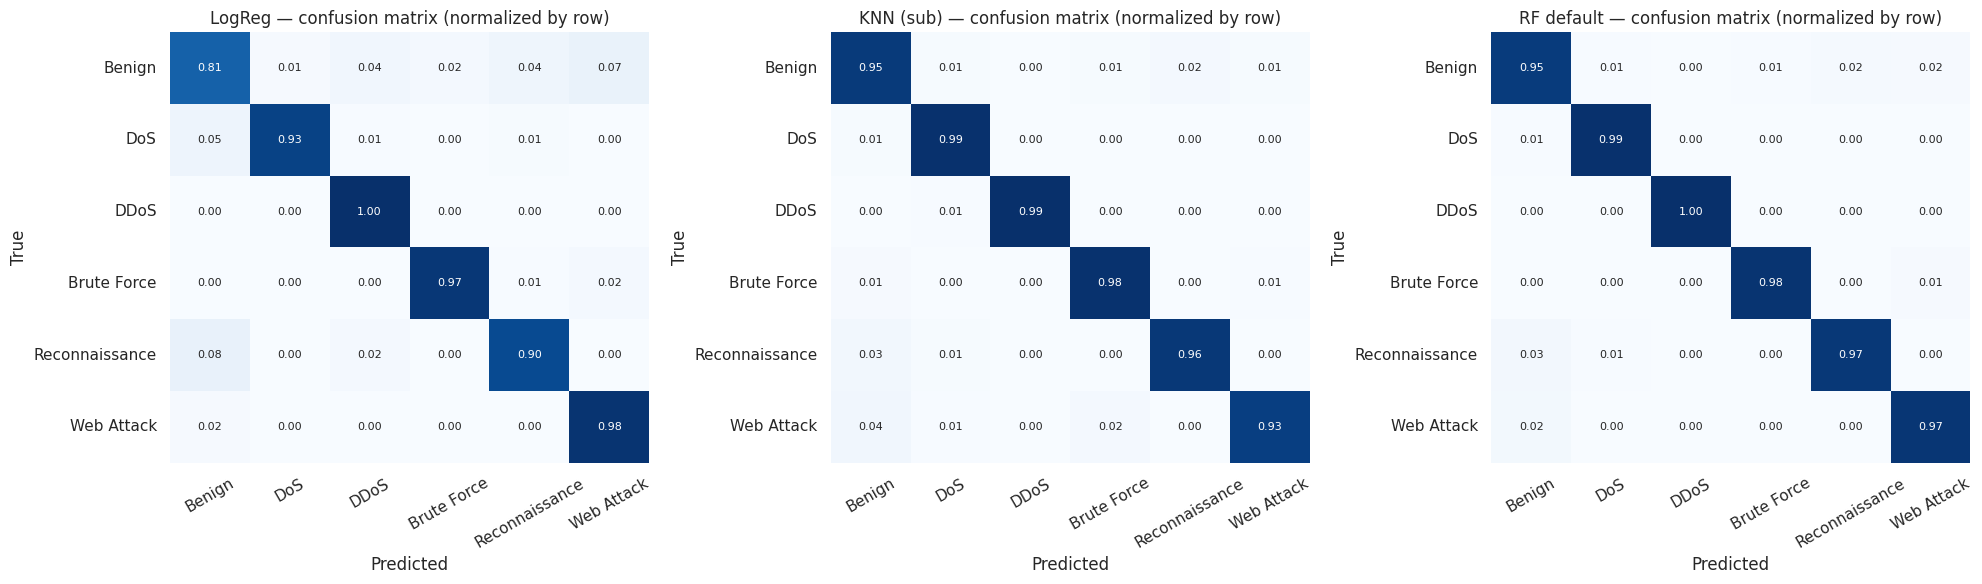

In [15]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
labels = ['Benign', 'DoS', 'DDoS', 'Brute Force', 'Reconnaissance', 'Web Attack']

for ax, (name, y_true, y_pred) in zip(axes, [
    ('LogReg', y_val, y_pred_lr),
    ('KNN (sub)', y_val_knn, y_pred_knn),
    ('RF default', y_val, y_pred_rf),
]):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
                annot_kws={'size': 8})
    ax.set_title(f'{name} — confusion matrix (normalized by row)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 7. Conclusiones

| Modelo | F1-macro (val full) | F1-macro (val balanced) | Inferencia/1K flujos |
|---|---|---|---|
| LogReg | **0.49** | 0.85 | 0.0002 s |
| KNN | n/a (costoso) | 0.95 | 0.024 s |
| RF default | **0.64** | **0.95** | 0.001 s |

**Lecturas**:

1. **RF default ya gana** en ambas vistas (full y balanced) sin tuning.
   En sample balanceado iguala a KNN pero con inferencia 24× más rápida.
2. **Brecha entre val balanced (0.95) y val full (0.64) en RF**: la vista
   "real" (con la distribución natural) sufre por **precision baja en
   clases minoritarias**. Web Attack tiene 322 casos en val pero el modelo
   los predice frecuentemente, generando muchos falsos positivos. Recall
   está alto (~0.97) pero precision queda en ~0.07.
3. **LogReg es muy débil en F1-macro full** (0.49). Confirma que la tarea
   no es linealmente separable en el espacio de features actuales.
4. **KNN escala mal**: inferencia 0.024s/1K vs 0.001s/1K de RF. Sobre
   347K val full tomaría ~8 segundos; en producción real con miles de
   flujos/seg, queda fuera.

**Headroom para el notebook 05**:

El target de tuning es subir el F1-macro en val FULL (de 0.64) cerrando el
gap con val balanced (0.95). Estrategias a explorar:

- `n_estimators` más alto (200-500) para reducir varianza en minorías.
- `class_weight='balanced_subsample'` o pesos custom.
- `min_samples_leaf` ajustado para evitar overfitting a muestras minoritarias.
- `max_features='sqrt'` vs valores fijos.

**Output persistido**:

`datasets/processed/cicids_split.parquet` con columna `split` para que
notebooks 05 y 06 reusen exactamente el mismo train/val/test.